In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import polars as pl

root_path = "./dataset_04/"

## Notes
- dataset_01 has the original experimental design with edge length L = 2.0
- dataset_02 has the edge length set to 1.0, and actually had no impact
- dataset_03 keeps the edge length set to 1.0, but the mass of the predators is increased to 3.0, and the number of times steps per episode is set to 200.

So far what I am seeing is the simulation works. The problem is 100 time steps is not sufficient for the prey to really learn anything. They just mostly standing place and don't move.

Also, 2000 episodes is way too many. They start to learn how to formulate swarms at around 200 or so episodes. So these experiments basically need to get ran with a shorter number of episodes and around 500-1000 time steps.

We also need to look at DoS and DoA for each time step. That way to can actually view what they are doing, and even visually spot things such as cohesion (dramatic increase in DoD and DoA within an episode).

In [2]:
os.listdir(root_path)

['baseline',
 'training_20_prey_3_fov',
 'training_20_prey_8_fov',
 'training_5_prey_3_fov',
 'training_5_prey_8_fov',
 'config',
 'eval.sh',
 'submit.sh']

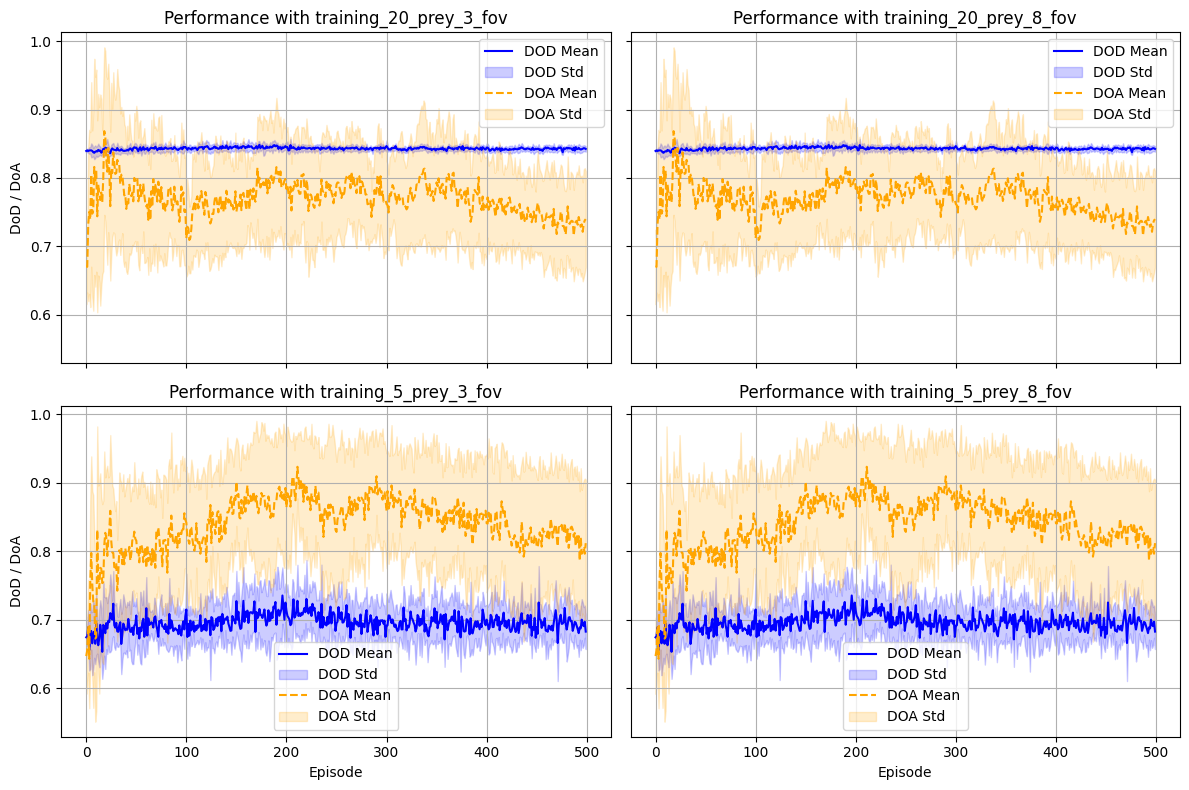

In [6]:
# load training data

def compute_seed_mean_and_std(factor_path, kernel_size=5, metric_name='metrics.csv'):
    dos_metrics = []
    doa_metrics = []

    for run in os.listdir(factor_path):  # limit to first 5 runs for speed
        training_metrics = pl.read_csv(os.path.join(factor_path, run, metric_name))
        dos_metrics.append(training_metrics['dos'].to_numpy())
        doa_metrics.append(training_metrics['doa'].to_numpy())

    # compute mean and std across seeds
    dos_mean = np.mean(dos_metrics, axis=0)
    dos_std = np.std(dos_metrics, axis=0)
    doa_mean = np.mean(doa_metrics, axis=0)
    doa_std = np.std(doa_metrics, axis=0)

    # dos_ma = np.convolve(dos, np.ones(window_size)/window_size, mode='valid')
    kernel = np.ones(kernel_size) / kernel_size
    dos_mean = np.convolve(dos_mean, kernel, mode='same')
    doa_mean = np.convolve(doa_mean, kernel, mode='same')

    dos_std  = np.convolve(dos_std,  kernel, mode='same')
    doa_std  = np.convolve(doa_std,  kernel, mode='same')

    return dos_mean, dos_std, doa_mean, doa_std

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

dod_color = 'blue'
doa_color = 'orange'
factors = [factor for factor in os.listdir(root_path) if factor != "baseline"]
file_name = "metrics.csv"

for idx, factor in enumerate(factors):
    factor_path = os.path.join(root_path, factor)
    #print(f"Processing factor: {factor}")
    if factor == "config" or os.path.isdir(factor_path) == False:
        continue

    dos_mean, dos_std, doa_mean, doa_std = compute_seed_mean_and_std(
        factor_path, 1, file_name)

    i, j = idx // 2, idx % 2

    # plot dod (1 - dos)
    dod_mean = 1 - dos_mean
    axes[i, j].plot(dod_mean, label='DOD Mean', color=dod_color)
    axes[i, j].fill_between(range(len(dod_mean)), dod_mean - dos_std, dod_mean + dos_std, alpha=0.2, label='DOD Std', color=dod_color)

    # plot doa
    axes[i, j].plot(doa_mean, '--', label='DOA Mean', color=doa_color)
    axes[i, j].fill_between(range(len(doa_mean)), doa_mean - doa_std, doa_mean + doa_std, alpha=0.2, label='DOA Std', color=doa_color)

    axes[i, j].set_title(f'Performance with {factor}')
    axes[i, j].legend()
    axes[i, j].grid(True)

axes[1, 0].set_xlabel('Episode')
axes[1, 1].set_xlabel('Episode')
axes[0, 0].set_ylabel('DoD / DoA')
axes[1, 0].set_ylabel('DoD / DoA')
plt.tight_layout()
plt.show()

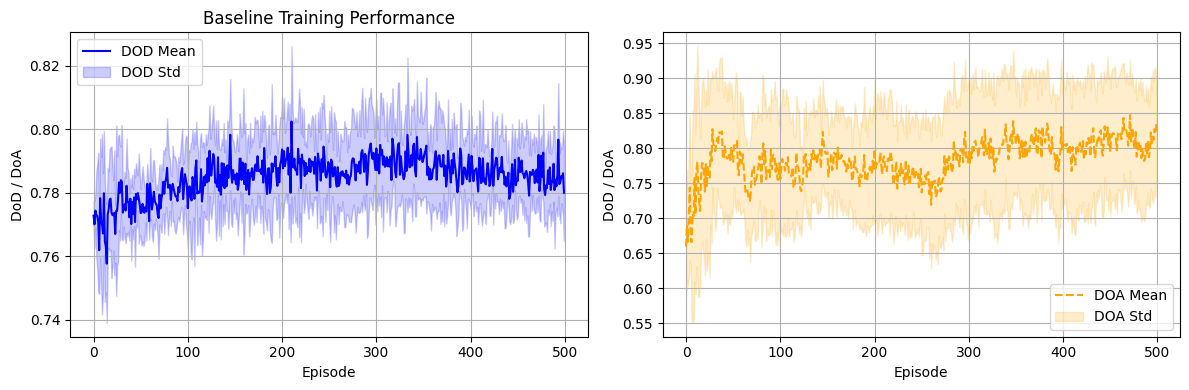

In [7]:
# baseline results
baseline_path = os.path.join(root_path, "baseline")
dos_mean, dos_std, doa_mean, doa_std = compute_seed_mean_and_std(baseline_path, 1, file_name)
# plt.figure(figsize=(6, 4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(1 - dos_mean, label='DOD Mean', color=dod_color)
axes[0].fill_between(range(len(1 - dos_mean)), 1 - dos_mean - dos_std, 1 - dos_mean + dos_std, alpha=0.2, label='DOD Std', color=dod_color)
axes[1].plot(doa_mean, '--', label='DOA Mean', color=doa_color)
axes[1].fill_between(range(len(doa_mean)), doa_mean - doa_std, doa_mean + doa_std, alpha=0.2, label='DOA Std', color=doa_color)
axes[0].set_title('Baseline Training Performance')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('DoD / DoA')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('DoD / DoA')
axes[0].grid(True)
axes[1].grid(True)
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

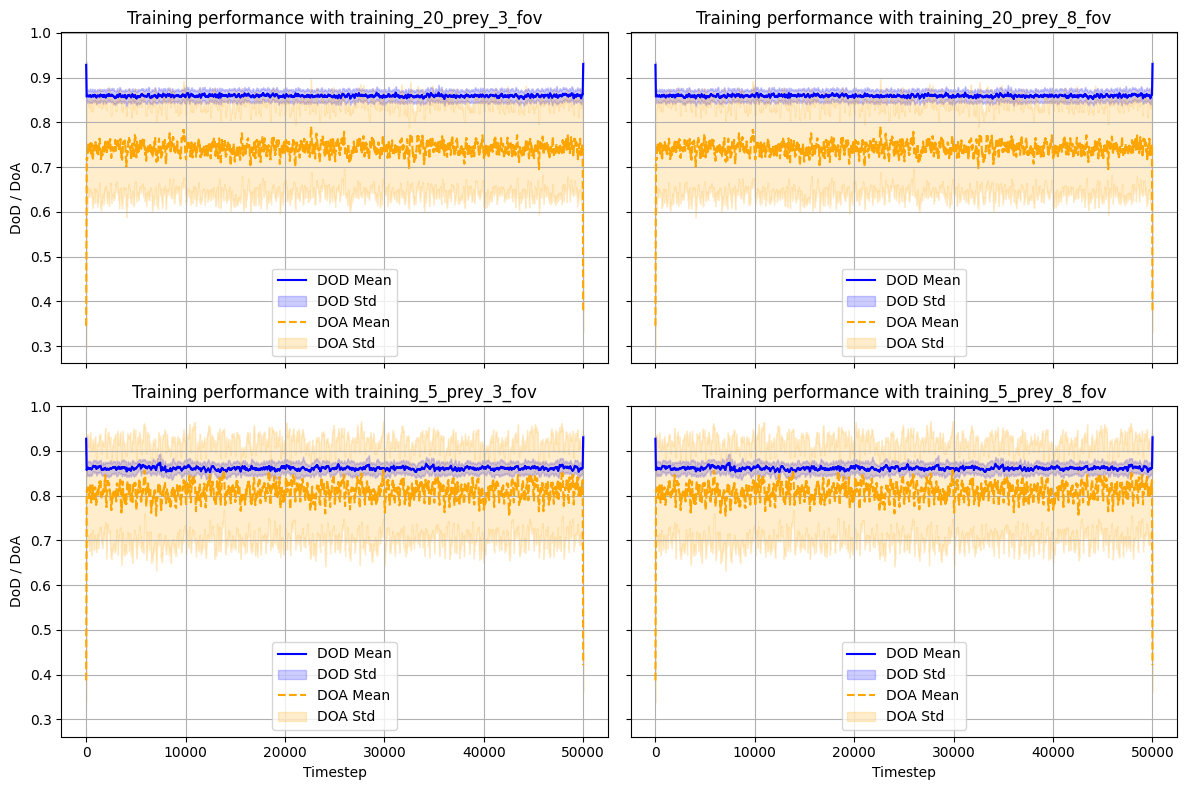

In [5]:
# per time step DoD and DoA for each factor
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

for idx, factor in enumerate(factors):
    factor_path = os.path.join(root_path, factor)
    # print(f"Processing factor: {factor}")
    if factor == "config" or os.path.isdir(factor_path) == False:
        continue

    dos_mean, dos_std, doa_mean, doa_std = compute_seed_mean_and_std(
        factor_path, 100, 'eval_metrics_with_predators_timesteps.csv')

    i, j = idx // 2, idx % 2

    # plot dod (1 - dos)
    dod_mean = 1 - dos_mean
    axes[i, j].plot(dod_mean, label='DOD Mean', color=dod_color)
    axes[i, j].fill_between(range(len(dod_mean)), dod_mean - dos_std,
                            dod_mean + dos_std, alpha=0.2, label='DOD Std', color=dod_color)

    # plot doa
    axes[i, j].plot(doa_mean, '--', label='DOA Mean', color=doa_color)
    axes[i, j].fill_between(range(len(doa_mean)), doa_mean - doa_std,
                            doa_mean + doa_std, alpha=0.2, label='DOA Std', color=doa_color)

    axes[i, j].set_title(f'Training performance with {factor}')
    axes[i, j].legend()
    axes[i, j].grid(True)

axes[1, 0].set_xlabel('Timestep')
axes[1, 1].set_xlabel('Timestep')
axes[0, 0].set_ylabel('DoD / DoA')
axes[1, 0].set_ylabel('DoD / DoA')
plt.tight_layout()
plt.show()